# 05 — Climate Features (PRISM)

Pull PRISM 4km climate normals for the Emerald Triangle and compute
per-cell statistics.

**Variables:**

| PRISM variable | Description | Cannabis relevance |
|---|---|---|
| `tmean` | Annual mean temp (°C) | Growing season thermal window |
| `tmin` | Mean minimum temp (°C) | Frost risk proxy |
| `tmax` | Mean maximum temp (°C) | Heat stress |
| `ppt` | Annual precipitation (mm) | Water availability |
| `vpdmax` | Max vapor pressure deficit (hPa) | Mold risk above ~20 hPa peak |
| `tdmean` | Mean dew point (°C) | Humidity / mold risk |

From these we derive:
- `gdd` — growing degree days (base 10°C), proxy for season length
- `frost_free_days` — estimated from tmin
- `dry_season_frac` — fraction of precip falling Oct–Mar vs annual

**Data source:** PRISM Climate Group, Oregon State University  
https://prism.oregonstate.edu/normals/ (800m normals, 1991–2020)  
No API key required.

**Outputs:**
- `data/raw/prism/` — downloaded PRISM rasters
- `data/processed/climate_features.pkl` — per-cell climate DataFrame

In [1]:
from pathlib import Path
import zipfile
import subprocess
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
IMG  = Path('../img')
PRISM_DIR = RAW / 'prism'
PRISM_DIR.mkdir(exist_ok=True)

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Build climate images in GEE

In [2]:
import ee
import requests

ee.Initialize(project='ee-simonhansedasi')  # same project as notebook 04

study_area = gpd.read_file(RAW / 'study_area.gpkg').to_crs('EPSG:4326')
bounds = study_area.total_bounds
roi = ee.Geometry.BBox(
    float(bounds[0]), float(bounds[1]),
    float(bounds[2]), float(bounds[3])
)

# Daymet V4 in GEE — average over 2021-2023
daymet = (
    ee.ImageCollection('NASA/ORNL/DAYMET_V4')
    .filterBounds(roi)
    .filterDate('2021-01-01', '2023-12-31')
    .select(['tmin', 'tmax', 'prcp', 'vp'])
)

tmin_img  = daymet.select('tmin').mean().clip(roi)
tmax_img  = daymet.select('tmax').mean().clip(roi)
prcp_img  = daymet.select('prcp').mean().multiply(365).clip(roi)
vp_img    = daymet.select('vp').mean().clip(roi)

# VPD = saturated VP(tmax) - actual VP (Pa)
sat_vp   = tmax_img.expression(
    '610.7 * pow(10, 7.5 * tmax / (237.3 + tmax))', {'tmax': tmax_img}
)
vpd_img   = sat_vp.subtract(vp_img).max(ee.Image(0)).rename('vpd')
tmean_img = tmax_img.add(tmin_img).divide(2).rename('tmean')
ffd_img   = tmin_img.multiply(12).add(240).clamp(0, 365).rename('ffd')

imgs = {
    'tmean':  tmean_img,
    'tmin':   tmin_img.rename('tmin'),
    'tmax':   tmax_img.rename('tmax'),
    'ppt':    prcp_img.rename('ppt'),
    'vpdmax': vpd_img,
    'ffd':    ffd_img,
}
print('GEE images ready:', list(imgs.keys()))

/home/simonhans/anaconda3/lib/python3.7/site-packages/google/auth/crypt/_cryptography_rsa.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  import cryptography.exceptions


GEE images ready: ['tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd']


## 2. Download GEE images as GeoTIFFs

In [3]:
PRISM_DIR.mkdir(exist_ok=True)
prism_tifs = {}

for var, img in imgs.items():
    out_path = PRISM_DIR / f'{var}.tif'
    if out_path.exists():
        print(f'  {var}: cached')
        prism_tifs[var] = out_path
        continue

    print(f'  {var}: downloading...')
    url = img.getDownloadURL({
        'region': roi,
        'scale':  1000,
        'format': 'GEO_TIFF',
        'crs':    'EPSG:4326',
    })
    r = requests.get(url, timeout=300, stream=True)
    r.raise_for_status()
    with open(out_path, 'wb') as f:
        for chunk in r.iter_content(1 << 20):
            f.write(chunk)
    prism_tifs[var] = out_path
    print(f'    saved {out_path.stat().st_size/1e6:.1f} MB')

print('Done:', list(prism_tifs.keys()))

  tmean: cached
  tmin: cached
  tmax: cached
  ppt: cached
  vpdmax: cached
  ffd: cached
Done: ['tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd']


## 3. Zonal statistics per hex cell

In [4]:
import subprocess

hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
study_utm = gpd.read_file(RAW / 'study_area.gpkg')
b = study_utm.total_bounds

# Warp each GEE tif to UTM 10N, then run zonal stats
frames = [hex_grid[['cell_id']].reset_index(drop=True)]

for var, src_path in prism_tifs.items():
    utm_path = PRISM_DIR / f'{var}_utm.tif'
    if not utm_path.exists():
        subprocess.run([
            'gdalwarp',
            '-t_srs', 'EPSG:32610',
            '-te', str(b[0]), str(b[1]), str(b[2]), str(b[3]),
            '-tr', '1000', '1000',
            '-r', 'bilinear',
            '-co', 'COMPRESS=LZW',
            str(src_path), str(utm_path),
        ], check=True, capture_output=True)

    print(f'  {var}...')
    stats = zonal_stats(
        hex_grid, str(utm_path),
        stats=['mean'], nodata=-9999, all_touched=False,
    )
    df = pd.DataFrame(stats).rename(columns={'mean': var})
    frames.append(df)

climate = pd.concat(frames, axis=1)
print(f'Shape: {climate.shape}')
print(climate.describe().round(2))

  tmean...
  tmin...
  tmax...
  ppt...
  vpdmax...
  ffd...
Shape: (8923, 7)
         tmean     tmin     tmax      ppt   vpdmax      ffd
count  8923.00  8923.00  8923.00  8923.00  8923.00  8923.00
mean     11.59     6.30    16.89  1232.72  1204.97   295.38
std       3.59     2.10     5.26   460.96   446.26    87.80
min       0.00     0.00     0.00     0.00     0.00     0.00
25%      11.59     5.73    16.51  1039.60  1019.49   308.48
50%      12.51     6.69    18.28  1285.81  1297.28   320.20
75%      13.33     7.47    19.59  1511.70  1485.67   329.70
max      16.16     9.56    23.55  2474.30  2125.08   355.09


## 4. Derive cannabis-relevant indices

In [5]:
# GDD (base 10°C) from tmin/tmax — the only derived feature not in Daymet
BASE_TEMP = 10.0
climate['gdd'] = np.maximum(
    ((climate['tmax'] + climate['tmin']) / 2) - BASE_TEMP, 0
) * 365

# Temperature range (diurnal proxy)
climate['temp_range'] = climate['tmax'] - climate['tmin']

print('Added: gdd, temp_range')
print()
print('Cannabis suitability check:')
print(f"  GDD > 1500:         {(climate['gdd'] > 1500).sum():,} / {len(climate):,} cells")
print(f"  frost_free > 150d:  {(climate['ffd'] > 150).sum():,} / {len(climate):,} cells")
print(f"  tmean 15-25C:       {climate['tmean'].between(15,25).sum():,} / {len(climate):,} cells")

Added: gdd, temp_range

Cannabis suitability check:
  GDD > 1500:         783 / 8,923 cells
  frost_free > 150d:  8,202 / 8,923 cells
  tmean 15-25C:       169 / 8,923 cells


## 5. Maps

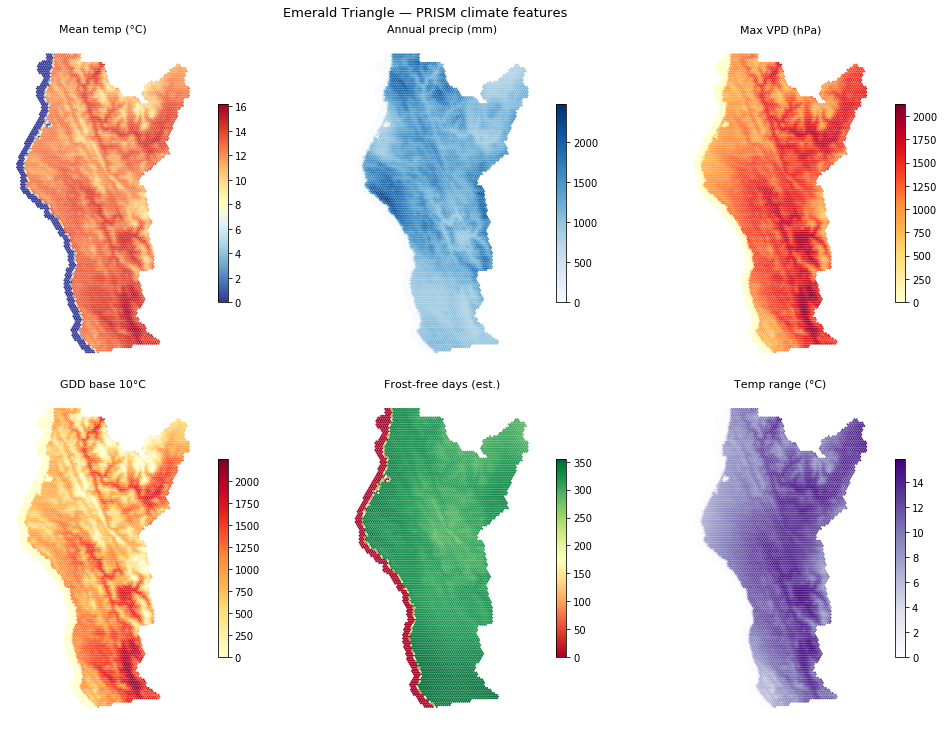

Saved img/05_climate.png


In [6]:
hex_feats = hex_grid.merge(climate, on='cell_id')

plot_vars = [
    ('tmean',          'Mean temp (°C)',        'RdYlBu_r'),
    ('ppt',            'Annual precip (mm)',     'Blues'),
    ('vpdmax',         'Max VPD (hPa)',          'YlOrRd'),
    ('gdd',            'GDD base 10°C',          'YlOrRd'),
    ('ffd','Frost-free days (est.)', 'RdYlGn'),
    ('temp_range',     'Temp range (°C)',        'Purples'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (col, title, cmap) in zip(axes.flat, plot_vars):
    hex_feats.plot(column=col, ax=ax, cmap=cmap, legend=True,
                   legend_kwds={'shrink': 0.6}, linewidth=0)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle('Emerald Triangle — PRISM climate features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../img/05_climate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/05_climate.png')

## 6. Save

In [7]:
out = PROC / 'climate_features.pkl'
climate.to_pickle(out)
print(f'Saved {out}')
print(f'Shape: {climate.shape}')
print(f'Columns: {climate.columns.tolist()}')
print()
print('Next: 06_soil_features.ipynb — USDA gSSURGO soil properties')

Saved ../data/processed/climate_features.pkl
Shape: (8923, 9)
Columns: ['cell_id', 'tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range']

Next: 06_soil_features.ipynb — USDA gSSURGO soil properties
